In [8]:
import json
import logging
import random
import os
from pathlib import Path
from typing import Optional

import numpy as np
from tqdm import tqdm
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from scipy.spatial import distance
import shutil
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
import seaborn

# Custom imports
import sys

sys.path.insert(1, "..")

from dependencies.data_generator import load_dataset
from dependencies.train_config import TrainConfig
from dependencies.GCN import (
    GAT_ver_1,
    GAT_ver_2,
    CustomDataset,
    TripletGraphDataset,
    train_model_accuracy,
    train_model_diversity,
    collate_triplets,
    collate_graphs,
)

In [9]:
with open("/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/surrogate_hp_dev.json") as conf_file:
    config = json.load(conf_file)

In [10]:
model = GAT_ver_2(
    input_dim=config["input_dim"],
    output_dim=config["div_output_dim"],
    dropout=config["div_dropout"],
    heads=config["div_n_heads"],
    output_activation="l2",
)

model.load_state_dict(torch.load("../surrogate_models/model_diversity.pth"))

<All keys matched successfully>

In [11]:
def load_dataset(
    path="/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/datasets/fashionmnist_archs",
) -> None:
    dataset_path = Path(path)

    models_dict_path = []
    for file_path in tqdm(dataset_path.rglob("*.json"), desc="Loading dataset"):
        models_dict_path.append(file_path)

    return models_dict_path

In [12]:
dataset_paths = load_dataset()
tmp_dataset_paths = load_dataset(
    "/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/results/cifar100_2/trained_models_archs"
)
darts_dataset_path_additional = load_dataset(
    "/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/results/cifar100/trained_models_archs"
)

darts_dataset_path_additional

Loading dataset: 785it [00:00, 162931.94it/s]
Loading dataset: 5it [00:00, 12031.85it/s]
Loading dataset: 5it [00:00, 12993.51it/s]


[PosixPath('/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/results/cifar100/trained_models_archs/model_4.json'),
 PosixPath('/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/results/cifar100/trained_models_archs/model_1.json'),
 PosixPath('/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/results/cifar100/trained_models_archs/model_0.json'),
 PosixPath('/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/results/cifar100/trained_models_archs/model_2.json'),
 PosixPath('/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/results/cifar100/trained_models_archs/model_3.json')]

In [13]:
dataset = CustomDataset(dataset_paths)
darts_dataset = CustomDataset(darts_dataset_path_additional)

In [14]:
def _prepare_predictions(dataset_paths, num_samples: Optional[int] = None):
    preds = []
    for path in tqdm(dataset_paths, desc="Preparing predictions"):
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        prediction_name = (
            "valid_predictions" if "valid_predictions" in data else "test_predictions"
        )
        arr = np.array(data[prediction_name])
        preds.append(arr[:num_samples] if num_samples else arr)
    return preds


def get_diversity_matrix(dataset_paths, num_samples: Optional[int] = None) -> None:
    n = len(dataset_paths)
    M = np.eye(n)
    preds = _prepare_predictions(dataset_paths, num_samples)
    for i in tqdm(range(n), desc="Computing diversity matrix (i loop)"):
        for j in range(i + 1, n):
            dist = np.mean(preds[i] == preds[j])
            M[i, j] = M[j, i] = dist
    return M

def create_discrete_diversity_matrix(M) -> None:
    upper = np.quantile(M, 0.8, axis=1)
    lower = np.quantile(M, 0.2, axis=1)
    D = np.zeros_like(M)
    D[M > upper[:, None]] = 1
    D[M < lower[:, None]] = -1

    return D

M = get_diversity_matrix(dataset_paths)
darts_M = get_diversity_matrix(darts_dataset_path_additional)

Computing diversity matrix (i loop): 100%|██████████| 5/5 [00:00<00:00, 8208.03it/s]


In [15]:
def get_all_embeddings(model, dataset, device=None):
    model.eval()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    embeddings = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)  # [1, D]
            embeddings.append(out.cpu().numpy().flatten())  # → [D]

    return np.array(embeddings)  # [N, D]

print("Computing embeddings for all models...")
embeddings = get_all_embeddings(model, dataset)  # [N, D]
darts_embeddings = get_all_embeddings(model, darts_dataset)
print(f"Embeddings shape: {embeddings.shape}")


Computing embeddings for all models...
Embeddings shape: (785, 8)


In [16]:
torch.manual_seed(42)
np.random.seed(42)

config = {
    "n_models": len(dataset),
    "train_size": 0.8,  # как в обучении
    "models_dict_path": dataset_paths,
}

accs = None


train_n = int(config["train_size"] * config["n_models"])
train_dataset, valid_dataset = random_split(dataset, [train_n, config["n_models"] - train_n])

# Получаем индексы
train_indices = train_dataset.indices
valid_indices = valid_dataset.indices

# Преобразуем в set для быстрого поиска
train_indices_set = set(train_indices)
valid_indices_set = set(valid_indices)


In [17]:
n_samples = 100000
N = config["n_models"]

np.random.seed(42)
darts_pairs = [
    (i, j)
    for i in range(len(darts_dataset_path_additional))
    for j in range(i+1, len(darts_dataset_path_additional))
]
pairs = [tuple(np.random.choice(N, 2, replace=False)) for _ in range(n_samples)]

embedding_distances = []
prediction_agreements = []
pair_types = []  # "train", "valid", "mixed"

with torch.no_grad():
    for i, j in pairs:
        # Эмбеддинговое расстояние
        dist = euclidean(embeddings[i], embeddings[j])
        embedding_distances.append(dist)

        # Доля совпадающих ответов
        agreement = M[i, j]
        prediction_agreements.append(agreement)

        # Определяем тип пары
        i_in_train, j_in_train = i in train_indices_set, j in train_indices_set
        if i_in_train and j_in_train:
            pair_types.append("train")
        elif i not in train_indices_set and j not in train_indices_set:
            pair_types.append("valid")
        else:
            pair_types.append("mixed")
with torch.no_grad():
    for i, j in darts_pairs:
        dist = euclidean(darts_embeddings[i], darts_embeddings[j])
        embedding_distances.append(dist)
        agreement = darts_M[i, j]
        prediction_agreements.append(agreement)
        pair_types.append("ensemble_models")

# Векторизуем
embedding_distances = np.array(embedding_distances)
prediction_agreements = np.array(prediction_agreements)
pair_types = np.array(pair_types)

Pair Type       | Count  | Pearson Corr | Mean Agreement  | Mean Dist
--------------------------------------------------------------------------------
Train           | 64061  |       -0.581 |          0.895 | 0.940
Valid           | 4028   |       -0.642 |          0.894 | 0.967
Mixed           | 31911  |       -0.605 |          0.895 | 0.954
Ensemble_models | 10     |        0.093 |          0.800 | 0.404

✅ Overall Pearson correlation (surrogate models): -0.591
✅ Overall Pearson correlation (DARTS models): 0.093


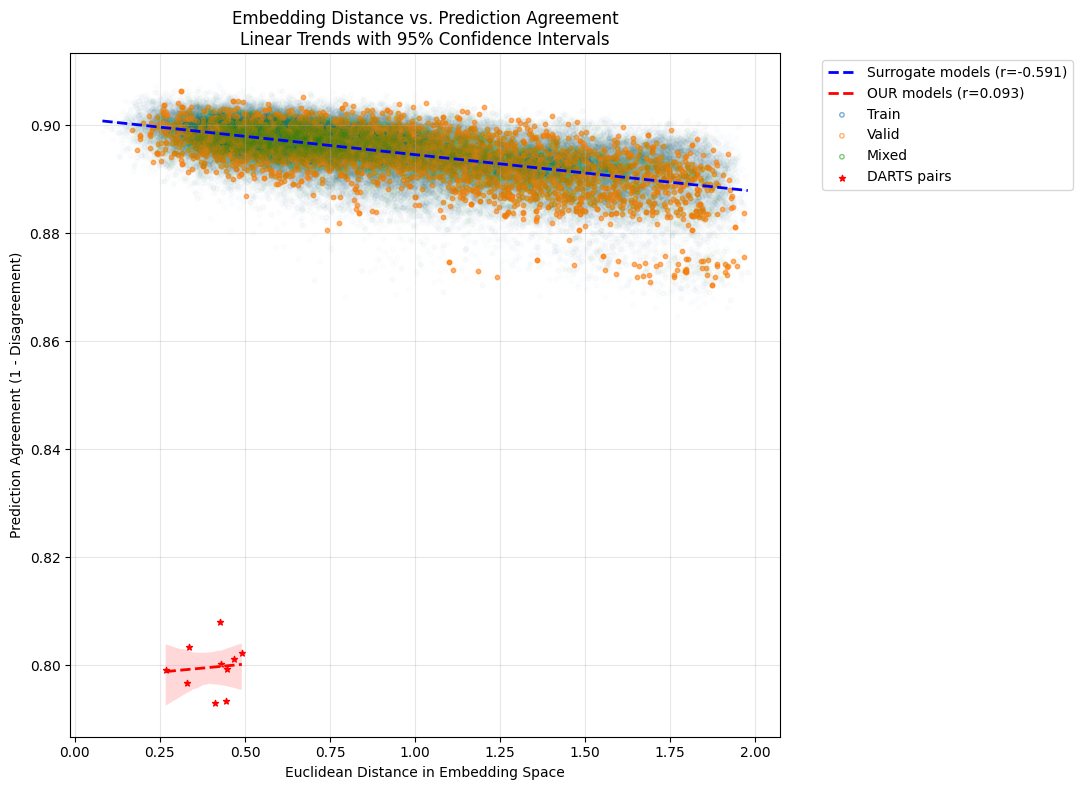

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Вывод таблицы ---
print(
    f"{'Pair Type':<15} | {'Count':<6} | {'Pearson Corr':<12} | {'Mean Agreement':<15} | {'Mean Dist'}"
)
print("-" * 80)

colors = {
    "train": "#1f77b4",      # синий
    "valid": "#ff7f0e",      # оранжевый
    "mixed": "#2ca02c",      # зелёный
    "ensemble_models": "red" # красный
}

# Собираем данные для двух групп
mask_surrogate = pair_types != "ensemble_models"
mask_darts = pair_types == "ensemble_models"

x_surrogate = embedding_distances[mask_surrogate]
y_surrogate = prediction_agreements[mask_surrogate]

x_darts = embedding_distances[mask_darts]
y_darts = prediction_agreements[mask_darts]

# Выводим статистику по типам
for ptype, color in colors.items():
    mask = pair_types == ptype
    x = embedding_distances[mask]
    y = prediction_agreements[mask]

    if len(x) < 2:
        corr = float("nan")
    else:
        corr = np.corrcoef(x, y)[0, 1]

    mean_agree = y.mean()
    mean_dist = x.mean()
    count = len(x)

    print(
        f"{ptype.capitalize():<15} | {count:<6} | {corr:12.3f} | {mean_agree:14.3f} | {mean_dist:.3f}"
    )

# Итоговые корреляции
corr_surrogate = np.corrcoef(x_surrogate, y_surrogate)[0, 1]
corr_darts = np.corrcoef(x_darts, y_darts)[0, 1]
print(f"\n✅ Overall Pearson correlation (surrogate models): {corr_surrogate:.3f}")
print(f"✅ Overall Pearson correlation (DARTS models): {corr_darts:.3f}")

# --- Визуализация с доверительными интервалами ---
plt.figure(figsize=(11, 8))

# Подготовка данных для seaborn
import pandas as pd

df_surrogate = pd.DataFrame({
    'distance': x_surrogate,
    'agreement': y_surrogate,
    'group': 'Surrogate Models'
})

df_darts = pd.DataFrame({
    'distance': x_darts,
    'agreement': y_darts,
    'group': 'DARTS Ensemble'
})

# Объединяем для легенды
df_plot = pd.concat([df_surrogate, df_darts], ignore_index=True)

# Цвета для regplot (можно задать вручную)
palette = {'Surrogate Models': 'blue', 'DARTS Ensemble': 'red'}

# Рисуем регрессии с доверительными интервалами (по умолчанию 95%)
sns.regplot(
    data=df_surrogate,
    x='distance', y='agreement',
    scatter=False,
    color=palette['Surrogate Models'],
    label=f"Surrogate models (r={corr_surrogate:.3f}, slope={np.polyfit(x_surrogate, y_surrogate, 1)[0]:.3f})",
    ci=95,
    line_kws={'linestyle': '--', 'linewidth': 2}
)

sns.regplot(
    data=df_darts,
    x='distance', y='agreement',
    scatter=False,
    color=palette['DARTS Ensemble'],
    label=f"DARTS models (r={corr_darts:.3f}, slope={np.polyfit(x_darts, y_darts, 1)[0]:.3f})",
    ci=95,
    line_kws={'linestyle': '--', 'linewidth': 2}
)

# Теперь добавим точки вручную, чтобы сохранить цвета по типам
for ptype, color in colors.items():
    mask = pair_types == ptype
    x = embedding_distances[mask]
    y = prediction_agreements[mask]
    alpha = 0.6 if ptype == "valid" else 0.01
    if ptype == "ensemble_models":
        plt.scatter(x, y, c=color, alpha=1.0, s=20, marker="*", label=f"{ptype}")
    else:
        plt.scatter(x, y, c=color, alpha=alpha, s=10, label=f"{ptype.capitalize()}")

# Оформление
plt.xlabel("Euclidean Distance in Embedding Space")
plt.ylabel("Prediction Agreement (1 - Disagreement)")
plt.title(
    "Embedding Distance vs. Prediction Agreement\n"
    "Linear Trends with 95% Confidence Intervals"
)
plt.grid(True, alpha=0.3)

# Легенда: сначала regplot-линии, потом scatter-точки
# Чтобы легенда не дублировалась, можно вручную собрать
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    # Линии тренда
    Line2D([0], [0], color='blue', linestyle='--', linewidth=2,
           label=f'Surrogate models (r={corr_surrogate:.3f})'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2,
           label=f'OUR models (r={corr_darts:.3f})'),
    # Точки
    plt.scatter([], [], c='none', edgecolors='#1f77b4', s=10, alpha=0.6, label='Train'),
    plt.scatter([], [], c='none', edgecolors='#ff7f0e', s=10, alpha=0.6, label='Valid'),
    plt.scatter([], [], c='none', edgecolors='#2ca02c', s=10, alpha=0.6, label='Mixed'),
    plt.scatter([], [], c='red', s=20, alpha=1.0, marker='*', label='DARTS pairs')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne(embeddings, title, labels=None, colors=None, marker_size=50):
    """
    Строит t-SNE визуализацию для заданных эмбеддингов.
    
    Параметры:
    - embeddings: np.array [N, D]
    - title: заголовок графика
    - labels: list of str, подписи для легенды (если есть)
    - colors: list of colors [N], цвета точек
    """
    # Уменьшаем размерность
    tsne = TSNE(n_components=2, perplexity=min(15, len(embeddings)-1), max_iter=1000, random_state=42, init='pca')
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(
        embeddings_2d[:, 0], embeddings_2d[:, 1],
        c=colors if colors is not None else 'blue',
        cmap='viridis' if colors is not None and isinstance(colors, np.ndarray) else None,
        alpha=0.8,
        s=marker_size,
        edgecolors='k' if marker_size < 100 else 'none',
        linewidth=0.3
    )

    plt.title(title, fontsize=14)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, alpha=0.3)

    # Если есть labels — добавим легенду
    if labels is not None:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=plt.cm.viridis(i / len(labels)), label=label)
                           for i, label in enumerate(labels)]
        plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    return embeddings_2d


In [ ]:
# # === t-SNE: Наши инференсные модели (например, DARTS или отобранные) ===
# print("🔧 Computing t-SNE for inference (OUR) models...")
# _ = plot_tsne(
#     darts_embeddings,
#     title="t-SNE: Embeddings of Inference Models (e.g., DARTS)\n"
#           "Structure of models used in deployment/ensembles",
#     marker_size=80
# )

# # === t-SNE: Все остальные модели (на которых обучался суррогат) ===
# print("\n🔧 Computing t-SNE for surrogate models...")
# _ = plot_tsne(
#     embeddings,
#     title="t-SNE: Embeddings of Surrogate Models (Training/Validation Set)\n"
#           "Structure of models used for surrogate training",
#     marker_size=60
# )

: 